In [ ]:
#데이터
##https://docs.ultralytics.com/datasets/detect/visdrone/#dataset-yaml

In [1]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 68.3 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 43.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 69.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 57.8 MB/s  0:00:08:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 67.2 MB/s  0:00:05:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 73.3 MB/s  0:00:02:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 72.3 MB/s  0:00:00m0:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 73.4 MB/s  0:00:01:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 68.5 MB/s  0:00:02:00:0100:01
     ━━━━━━━━━━━━━━━

In [1]:

import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))


2.7.1+cu118
True
2
NVIDIA TITAN Xp


In [6]:
pip install ultralytics

  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 42.4 MB/s  0:00:00m0:00:01
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 70.4 MB/s  0:00:00m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 31.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 MB 52.0 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 31.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from pathlib import Path

visdrone_yaml = """# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# VisDrone2019-DET dataset https://github.com/VisDrone/VisDrone-Dataset by Tianjin University
# Documentation: https://docs.ultralytics.com/datasets/detect/visdrone/
# Example usage: yolo train data=VisDrone.yaml

# Dataset structure:
# parent
# ├── ultralytics
# └── datasets
#     └── VisDrone ← downloads here (2.3 GB)

# Train/val/test sets
path: VisDrone
train: images/train
val: images/val
test: images/test

# Classes
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor

# Download and conversion script
download: |
  import os
  from pathlib import Path
  import shutil

  from ultralytics.utils.downloads import download
  from ultralytics.utils import ASSETS_URL, TQDM

  def visdrone2yolo(dir, split, source_name=None):
      \"\"\"Convert VisDrone annotations to YOLO format.\"\"\"
      from PIL import Image

      source_dir = dir / (source_name or f"VisDrone2019-DET-{split}")
      images_dir = dir / "images" / split
      labels_dir = dir / "labels" / split
      labels_dir.mkdir(parents=True, exist_ok=True)

      if (source_images_dir := source_dir / "images").exists():
          images_dir.mkdir(parents=True, exist_ok=True)
          for img in source_images_dir.glob("*.jpg"):
              img.rename(images_dir / img.name)

      for f in TQDM((source_dir / "annotations").glob("*.txt"), desc=f"Converting {split}"):
          img_size = Image.open(images_dir / f.with_suffix(".jpg").name).size
          dw, dh = 1.0 / img_size[0], 1.0 / img_size[1]
          lines = []

          with open(f, encoding="utf-8") as file:
              for row in [x.split(",") for x in file.read().strip().splitlines()]:
                  if row[4] != "0":
                      x, y, w, h = map(int, row[:4])
                      cls = int(row[5]) - 1
                      x_center, y_center = (x + w / 2) * dw, (y + h / 2) * dh
                      w_norm, h_norm = w * dw, h * dh
                      lines.append(f"{cls} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\\n")

          (labels_dir / f.name).write_text("".join(lines), encoding="utf-8")

  dir = Path(yaml["path"])
  urls = [
      f"{ASSETS_URL}/VisDrone2019-DET-train.zip",
      f"{ASSETS_URL}/VisDrone2019-DET-val.zip",
      f"{ASSETS_URL}/VisDrone2019-DET-test-dev.zip",
  ]
  download(urls, dir=dir, threads=4)

  splits = {
      "VisDrone2019-DET-train": "train",
      "VisDrone2019-DET-val": "val",
      "VisDrone2019-DET-test-dev": "test"
  }
  for folder, split in splits.items():
      visdrone2yolo(dir, split, folder)
      shutil.rmtree(dir / folder)
"""

path = Path("VisDrone.yaml")
path.write_text(visdrone_yaml, encoding="utf-8")

print(f"✅ VisDrone.yaml created at: {path.resolve()}")


✅ VisDrone.yaml created at: <PROJECT_ROOT>


In [4]:
from pathlib import Path

vis_person_yaml = """# VisDrone person-only dataset
# pedestrian + people classes are merged into a single 'person' class
# This YAML assumes labels have already been remapped to person-only

path: VisDrone

train: images/train
val: images/val
test: images/test

nc: 1
names: ['person']
"""

yaml_path = Path("vis_person.yaml")
yaml_path.write_text(vis_person_yaml, encoding="utf-8")

print(f"✅ vis_person.yaml created at: {yaml_path.resolve()}")


✅ vis_person.yaml created at: <PROJECT_ROOT>


In [ ]:
# ### terminal command
# yolo train \
#   model=yolo11s.pt \
#   data=vis_person.yaml \
#   epochs=100 \
#   imgsz=960 \
#   batch=16 \
#   single_cls=True \
#   patience=20 \
#   device=0,1


In [1]:
pip install pandas

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 43.4 MB/s  0:00:00eta 0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd

# results.csv 경로
results_path = "<PROJECT_ROOT>"

# CSV 불러오기
df = pd.read_csv(results_path)

# 기준 지표 선택 (보통 mAP50-95 또는 mAP50)
best_idx = df["metrics/mAP50-95(B)"].idxmax()

best_epoch = int(df.loc[best_idx, "epoch"])
best_map = df.loc[best_idx, "metrics/mAP50-95(B)"]

print(f"Best epoch: {best_epoch}")
print(f"metrics/mAP50-95(B): {best_map:.4f}")


Best epoch: 86
metrics/mAP50-95(B): 0.4685


In [1]:
from ultralytics import YOLO

# 모델 로드
model = YOLO("<PROJECT_ROOT>")

model.model.names = {0: "person"}

# 이미지(또는 영상) 리스트
videos = [
    "s418.png",
    "s863.png",
    "s891.png"
]

# 하나씩 추론
for v in videos:
    results = model.predict(
        source=v,
        conf=0.15,        # confidence threshold
        iou=0.45,         # IoU threshold
        classes=[0],      # person only
        save=True,        # 결과 저장
        save_txt=False,
        show=False
    )



image 1/1 <PROJECT_ROOT> 288x832 11 persons, 73.5ms
Speed: 7.1ms preprocess, 73.5ms inference, 72.4ms postprocess per image at shape (1, 3, 288, 832)
Results saved to <PROJECT_ROOT>

image 1/1 <PROJECT_ROOT> 640x832 13 persons, 50.4ms
Speed: 3.2ms preprocess, 50.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 832)
Results saved to <PROJECT_ROOT>

image 1/1 <PROJECT_ROOT> 704x832 2 persons, 49.9ms
Speed: 6.1ms preprocess, 49.9ms inference, 1.0ms postprocess per image at shape (1, 3, 704, 832)
Results saved to <PROJECT_ROOT>


In [ ]:
#pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


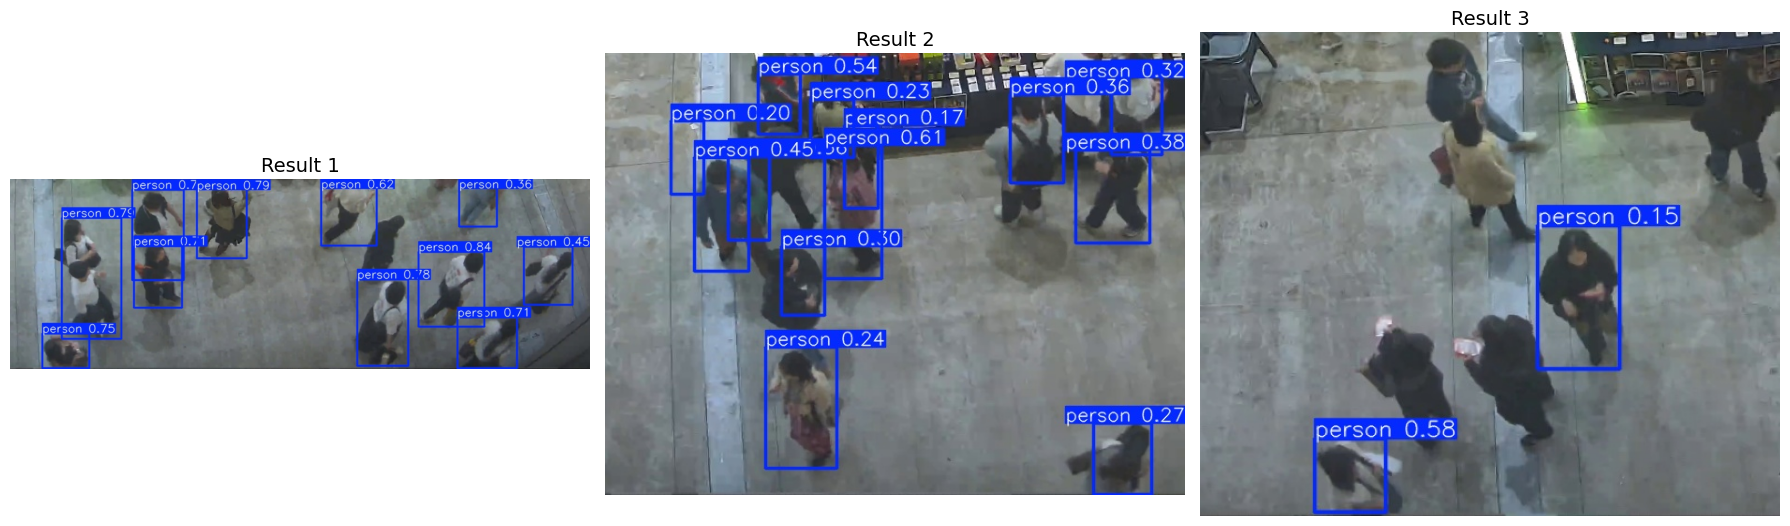

In [6]:
import cv2
import matplotlib.pyplot as plt

# 저장된 결과 이미지 경로
result_images = [
    "<PROJECT_ROOT>",
    "<PROJECT_ROOT>",
    "<PROJECT_ROOT>"
]

plt.figure(figsize=(18, 6))

for i, img_path in enumerate(result_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV → RGB

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Result {i+1}", fontsize=14)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [27]:
from ultralytics import YOLO

images = [
    "<PROJECT_ROOT>",
    "<PROJECT_ROOT>",
    "<PROJECT_ROOT>"
]

# pretrained model
pretrained = YOLO("yolo11s.pt")
pretrained.predict(
    source=images,
    conf=0.25,
    save=True,
    project="runs/compare",
    name="pretrained"
)

# fine-tuned model
finetuned = YOLO("<PROJECT_ROOT>")
finetuned.predict(
    source=images,
    conf=0.25,
    save=True,
    project="runs/compare",
    name="finetuned"
)



0: 640x640 13 persons, 2 suitcases, 6.3ms
1: 640x640 11 persons, 1 bird, 2 backpacks, 6.3ms
2: 640x640 5 persons, 6.3ms
Speed: 1.6ms preprocess, 6.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to <PROJECT_ROOT>

0: 960x960 16 items, 13.2ms
1: 960x960 11 items, 13.2ms
2: 960x960 5 items, 13.2ms
Speed: 3.3ms preprocess, 13.2ms inference, 0.6ms postprocess per image at shape (1, 3, 960, 960)
Results saved to <PROJECT_ROOT>


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'item'}
 obb: None
 orig_img: array([[[155, 152, 137],
         [154, 151, 136],
         [151, 148, 133],
         ...,
         [116, 121, 121],
         [114, 119, 119],
         [113, 118, 118]],
 
        [[154, 151, 136],
         [152, 149, 134],
         [151, 148, 133],
         ...,
         [117, 122, 122],
         [115, 120, 120],
         [114, 119, 119]],
 
        [[153, 150, 135],
         [151, 148, 133],
         [150, 147, 132],
         ...,
         [118, 123, 123],
         [117, 122, 122],
         [114, 119, 119]],
 
        ...,
 
        [[109, 106, 101],
         [107, 104,  99],
         [106, 103,  98],
         ...,
         [ 43,  41,  38],
         [ 46,  44,  41],
         [ 48,  47,  43]],
 
        [[107, 104, 103],
         [103, 100,  99],
         [103, 100,  99],
         ...,
         [ 41,  41, 

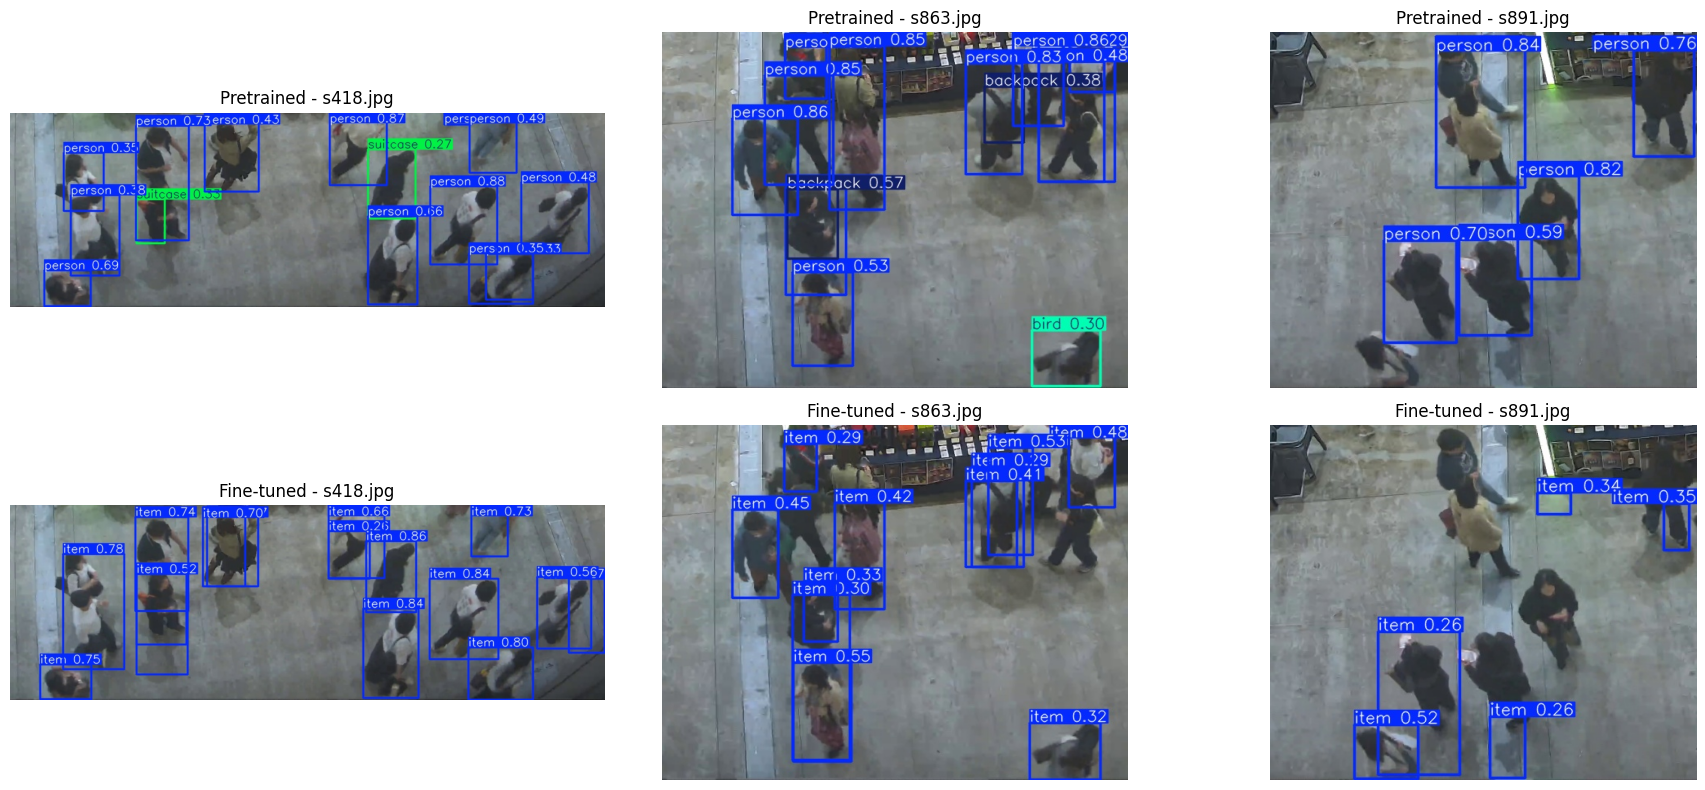

In [31]:
import cv2
import matplotlib.pyplot as plt
import os

img_names = ["s418.jpg", "s863.jpg", "s891.jpg"]

pre_dir = "runs/compare/pretrained2"
fin_dir = "runs/compare/finetuned2"

plt.figure(figsize=(18, 8))

for i, name in enumerate(img_names):
    # pretrained
    img_pre = cv2.imread(os.path.join(pre_dir, name))
    img_pre = cv2.cvtColor(img_pre, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_pre)
    plt.title(f"Pretrained - {name}")
    plt.axis("off")

    # finetuned
    img_fin = cv2.imread(os.path.join(fin_dir, name))
    img_fin = cv2.cvtColor(img_fin, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 4)
    plt.imshow(img_fin)
    plt.title(f"Fine-tuned - {name}")
    plt.axis("off")

plt.tight_layout()
plt.show()
